# Table extraction — where do the seconds go?

Pick **any form and any PDF from production**, run that form's table field with full timing
instrumentation, and get a per-operation breakdown plus a waterfall showing what actually
overlapped.

**Kernel: the `topics` conda env** (`/home/ubuntu/miniconda3/envs/topics/bin/python`). The
backend's DSPy/litellm stack lives there, not in `base`.

### What gets measured

| Operation | What it is | Calls |
|---|---|---|
| `record_discovery` | which records the paper reports — key columns only | 1 |
| `recall_audit` | second pass: *what did discovery miss?* | 1 |
| `slot_fill_set` | fill many records in one call (the current default) | ceil(n/k) |
| `slot_fill_row` | fill one record's attributes (`EXTRACTION_BATCH_VALUES=0`, and the fallback when a set call fails twice) | 1 per record |
| `refill` | targeted re-extraction of records that came back empty | 0–2 rounds |

Each LLM call is timed two ways: **our wall clock** around the awaited call, and litellm's own
`_response_ms` (`api_s`). `wall − api` is our own overhead — adapter rendering, JSON parsing,
reconciliation. The difference between `api_s_sum` and `busy_s` is the concurrency: sum adds
every call, `busy_s` is the union of their intervals, so `sum / busy` is the real speedup the
`asyncio.gather` fan-outs are buying.

### Two sources, both here

1. **Live run** (sections 1–4) — real Bedrock calls on a paper you choose. Costs tokens.
2. **Past production jobs** (section 5) — `llm_history.metadata.duration_ms` and the `jobs`
   table. Free, and it includes the Celery queue wait that an in-process run can't see.

DSPy's response cache is **disabled** by `bootstrap()`. A cached response returns in
microseconds, so timing one is not timing the pipeline.

## 0 · Parameters

Leave `FORM_ID` / `FIELD` / `DOC_IDS` as `None` on the first pass — section 1 prints the prod
tables to choose from, and the auto-pick fills them in so the notebook runs top-to-bottom
without editing anything.

In [1]:
# Nothing here needs to be known in advance. Leave it all as-is on the first run:
# section 1 prints every table field on prod, section 2 prints that project's PDFs.
# FORM_ID / DOC_IDS accept names as well as ids. Strings must be quoted.
#
# ── what to profile ────────────────────────────────────────────────────────
PROJECT_NAME = "Analgesics"
FORM_ID      = "Acute Dental Pain — Dichotomous Outcomes"
FIELD        = "dichotomous_outcomes"   # table field on that form, e.g. "outcomes". None → its only/first one
DOC_IDS         = ["A single-tablet fixed-dose combination of racemic ibuprofen/paracetamol in the management of moderate to severe postoperative dental pain in adult and adolescent patients: a multicenter, two-stage, randomized, double-blind, parallel-group, placebo-control"]    # ids and/or title fragments: ["ketoprofen", "meloxicam"]. None → first N_PAPERS
N_PAPERS        = 1       # used only when DOC_IDS is None. Each paper is a full extraction — the cost dial

# ── how to run it ──────────────────────────────────────────────────────────
MODEL_OVERRIDE   = None   # e.g. "anthropic/claude-haiku-4-5" — None = the form's production model
USE_MODEL_ROUTER = True   # True mirrors production (ModelRouter + dspy.context + circuit breaker)
PARALLEL_PAPERS  = False  # False = papers in sequence, so per-step numbers are uncontended

# ── prod history section ───────────────────────────────────────────────────
PROD_LOOKBACK_DAYS = 30
PROD_JOB_ID        = None  # pin one job instead of the whole window

SAVE = True               # write CSVs + JSON under eval/profiling/outputs/

In [2]:
import sys, asyncio, pandas as pd
sys.path.insert(0, "/home/ubuntu/evistream/backend/eval/profiling")
import table_timing as tt

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 60)

RUNTIME = tt.bootstrap()          # sys.path + prod secrets + DSPy config, cache off
pd.Series(RUNTIME).to_frame("value")

[secrets_loader] Loaded 30 secrets from 'evistream/production'
/home/ubuntu/miniconda3/envs/topics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-08-18 14:39:51,096 - root - INFO - Logging initialized: level=INFO, console only
2026-08-18 14:39:51,115 - utils.lm_config - INFO - EXTRACTION_PROMPT_CACHE=1 — installed CachingChatAdapter (active=CachingChatAdapter)
2026-08-18 14:39:51,116 - utils.gemini_json_unwrap - INFO - [gemini_json_unwrap] JSONAdapter.parse patched for Gemini list-unwrap
2026-08-18 14:39:51,117 - utils.lm_config - INFO - DSPy model initialization: Attempting with model anthropic/claude-sonnet-5 (1/3)
2026-08-18 14:39:51,118 - utils.lm_config - INFO - DSPy model initialization: Attempting with model anthropic/claude-sonnet-5 (1/3)


,value
model,anthropic/claude-sonnet-5
max_tokens,100000
adapter,CachingChatAdapter
dspy_response_cache,disabled (disk+memory)
EXTRACTION_PROMPT_CACHE,True
slot_filling,set-at-a-time
EXTRACTION_BATCH_VALUES,(unset → 1)
supabase,True
dspy_version,3.0.3


Read `slot_filling` in that table before anything else — it decides the shape of the whole run.
`EXTRACTION_BATCH_VALUES` is unset in production and **defaults to `1`** in
`runtime_builders`, i.e. set-at-a-time: one call carries up to ~40 records. Export
`EXTRACTION_BATCH_VALUES=0` before starting the kernel to measure the row-at-a-time path
instead (which is also what the set path falls back to when a batch fails twice).

`EXTRACTION_PROMPT_CACHE=1` means the paper is sent once and re-read from Anthropic's cache —
the first call of a paper pays the write, every later call reads it, which is exactly what the
`cache_read` / `cache_write` columns show.

## 1 · Pick a form and table field from production

`runs_as` is the column that matters: it mirrors the activation test in
`runtime_builders.build_schema_classes`, so a field that says `single_pass` here runs as one
call in production no matter what the form UI shows.

In [3]:
forms = tt.list_table_forms()

# The valid values for PROJECT_NAME, so it can be copied instead of guessed.
print("PROJECT_NAME options:")
display(forms.groupby("project")
             .agg(forms=("form_id", "nunique"), table_fields=("field", "size"),
                  keyed=("keyed_pipeline", "sum"))
             .sort_values("table_fields", ascending=False))

forms = tt.match_project(forms, PROJECT_NAME)   # exact name wins over substring

print(f"\n{len(forms)} table field(s) · keyed: {int(forms.keyed_pipeline.sum())}"
      f"  — copy a form_id (or the form_name) into FORM_ID above to pin one")
forms[["project", "form_name", "field", "runs_as", "n_key", "n_attr",
       "key_columns", "form_id"]].head(40)

✓ Supabase client initialized: https://wjgwfdmilhhxikqkytdg.supabase.co
PROJECT_NAME options:


,forms,table_fields,keyed
project,,,
Acute Dental Pain,3,9,2
Antibiotic prophylaxis,8,8,8
Periodontitis,8,8,8
Ibuprofen (Testing),6,6,4
Ibuprofen,6,6,4
Oral Cancer,4,4,4
Analgesics,3,3,3
Corticosteroids,3,3,3
Dental Implants,3,3,3



3 table field(s) · keyed: 3  — copy a form_id (or the form_name) into FORM_ID above to pin one


,project,form_name,field,runs_as,n_key,n_attr,key_columns,form_id
5,Analgesics,Acute Dental Pain — Interventions,interventions,keyed,3,8,"arm_description, arm_name, intervention_category",7e7fc5dc-6244-4926-94c4-4a3c29973f4d
28,Analgesics,Acute Dental Pain — Dichotomous Outcomes,dichotomous_outcomes,keyed,7,5,"adverse_effect, followup_timepoint, intervention, interv...",d9f6e1d9-449e-4aaa-a438-67923f77a448
35,Analgesics,Acute Dental Pain — Continuous Outcomes,continuous_outcomes,keyed,13,4,"central_tendency_measure, intervention, intervention_det...",ded9d6ab-e9e6-4ce2-b409-3ec740c3f6c0


In [4]:
# FORM_ID takes a UUID *or* a form name; FIELD narrows within it. With both None,
# the first keyed field is picked. Ambiguous matches raise and print the candidates.
sel, notes = tt.resolve_selection(forms, form=FORM_ID, field=FIELD)
for n in notes:
    print("⚠", n)

FORM_ID, FIELD = sel.form_id, sel.field
schema_def = tt.load_schema_def(FORM_ID)
sel.to_frame("selected")

,selected
project,Analgesics
project_id,dc4dfd37-0a73-4822-b113-fce614797b82
form_id,d9f6e1d9-449e-4aaa-a438-67923f77a448
form_name,Acute Dental Pain — Dichotomous Outcomes
schema_name,dynamic_d9f6e1d9_AcuteDentalPainDichotomousOutcomes
sig_class,ExtractAllDichotomousOutcomeRows
field,dichotomous_outcomes
strategy_raw,row_then_columns
strategy,discover_then_fill
runs_as,keyed


## 2 · Pick the paper(s)

Any document in the form's project that has markdown in S3 — that's the set the pipeline can
actually run on, so the table below is the menu.

`DOC_IDS` takes whatever you have to hand: document ids, filename/title fragments, or a mix —
one string or a list. `["ketoprofen", "meloxicam"]` is a valid selection. Left as `None`, the
first `N_PAPERS` rows run, so the notebook works untouched.

Cost scales linearly with the number of papers; wall clock does too unless you set
`PARALLEL_PAPERS = True`. Bigger papers and wider tables are where the interesting time goes.

In [5]:
docs = tt.list_documents(sel.project_id, limit=60)
print(f"{len(docs)} document(s) with markdown in project {sel.project!r}")
docs.head(30)

60 document(s) with markdown in project 'Analgesics'


,id,filename,title,page_count,processing_status,parse_quality_score,has_blocks,created_at
0,9ce49437-c881-45f8-a4cd-399ccb8b5df8,A single-tablet fixed-dose combination of racemic ibupro...,A single-tablet fixed-dose combination of racemic ibupro...,17.0,completed,None,True,2026-08-11T13:57:42.274542+00:00
1,abbf3405-75f8-45d5-a96b-26823143d4aa,Comparison of the analgesic efficacy of concurrent ibupr...,Comparison of the analgesic efficacy of concurrent ibupr...,14.0,completed,None,True,2026-08-11T13:57:41.971911+00:00
2,8c0b96a4-c616-431c-9f7e-6a9417663028,"Evaluation of ketorolac, aspirin, and an acetaminophen-c...","Evaluation of ketorolac, aspirin, and an acetaminophen-c...",17.0,completed,None,True,2026-08-11T13:11:53.997387+00:00
3,c9fcc42b-0ea1-474f-8504-b66eec222208,Comparison of ketoprofen ibuprofen and placebo in a dent...,Comparison of ketoprofen ibuprofen and placebo in a dent...,11.0,completed,None,True,2026-08-11T13:11:53.890107+00:00
4,c156a277-05cb-4e36-840b-53ff1cc3d959,A Randomized Double-Blind Controlled Trial of Intravenou...,A Randomized Double-Blind Controlled Trial of Intravenou...,13.0,completed,None,True,2026-08-11T13:11:53.74114+00:00
5,c5cef20d-7715-4146-a994-8a10faf30874,The analgesic efficacy of flurbiprofen compared to aceta...,The analgesic efficacy of flurbiprofen compared to aceta...,NaN,metadata_only,None,False,2026-08-11T13:11:53.587284+00:00
6,5b099064-66c4-4ac4-ad63-2e92c2734fb4,Analgesic Efficacy of an Acetaminophen/Ibuprofen Fixed-d...,Analgesic Efficacy of an Acetaminophen/Ibuprofen Fixed-d...,17.0,completed,None,True,2026-08-11T13:11:53.474928+00:00
7,580bd96e-047c-442c-9aee-febe38519e73,"Comparative study of flurbiprofen, zomepirac sodium, ace...","Comparative study of flurbiprofen, zomepirac sodium, ace...",5.0,completed,None,True,2026-08-11T13:11:53.266766+00:00
8,b70302ff-3dcd-464a-b1a4-cf5f701c13ba,"A double-blind comparison of ibuprofen, ASA-codeine-caff...","A double-blind comparison of ibuprofen, ASA-codeine-caff...",4.0,completed,None,True,2026-08-11T13:11:53.069708+00:00
9,5118c08f-1609-403b-8908-5ac98d6114ad,The comparative efficacy of aceclofenac and ibuprofen in...,The comparative efficacy of aceclofenac and ibuprofen in...,5.0,completed,None,True,2026-08-11T13:11:52.912757+00:00


In [6]:
# DOC_IDS accepts document ids, filename/title fragments, or a mix — one string or a
# list. None → the first N_PAPERS rows above. A fragment matching 2 papers raises.
doc_ids, picked = tt.resolve_documents(docs, DOC_IDS, n_default=N_PAPERS)
print(f"running {len(doc_ids)} paper(s):")
for i, (d, lbl) in enumerate(zip(doc_ids, picked), 1):
    print(f"  {i}. {lbl[:70]}  [{d}]")

papers = tt.fetch_papers(doc_ids)     # S3 → temp files, same bytes production sends
pd.DataFrame([{k: p.get(k) for k in ("label", "page_count", "chars", "est_tokens", "doc_id")}
              for p in papers])

running 1 paper(s):
  1. A single-tablet fixed-dose combination of racemic ibuprofen/paracetamo  [9ce49437-c881-45f8-a4cd-399ccb8b5df8]
2026-08-18 14:39:52,906 - app.services.storage_service - INFO - AWS credentials validated successfully


,label,page_count,chars,est_tokens,doc_id
0,A single-tablet fixed-dose combination of ra…,17,83918,20979,9ce49437-c881-45f8-a4cd-399ccb8b5df8


## 3 · Run it, instrumented

This makes real LLM calls. Cost per paper is `2 + ceil(records/40)` calls on the set-at-a-time
default, or `2 + records` on the row-at-a-time path, plus any refill round.

`profile_field` builds the extractor through `build_schema_classes` — the same selection
production makes — and runs it inside `ModelRouter.run_with_routing`, so the LM, the
`CachingChatAdapter`, and the circuit breaker all behave as they do in a real job.

In [ ]:
run = await tt.profile_field(
    schema_def, FIELD, papers,
    use_model_router=USE_MODEL_ROUTER,
    model_override=MODEL_OVERRIDE,
    parallel_papers=PARALLEL_PAPERS,
)
print(f"pipeline: {run.runs_as}  ·  signature: {run.sig_class}  ·  model: {run.model}")
if run.errors:
    print("ERRORS:", run.errors)
print() 
print(tt.overhead_report(run))

2026-08-18 14:39:55,134 - dspy_components.runtime_builders - INFO - Keyed extractor for ExtractAllDichotomousOutcomeRows — composite key=['adverse_effect', 'followup_timepoint', 'intervention', 'intervention_detail', 'outcome_other', 'outcome_type', 'population_type'], attributes=5
2026-08-18 14:39:55,146 - utils.circuit_breaker - INFO - [ModelRouter] Initialized with models: ['anthropic/claude-sonnet-5', 'openai/gpt-4o', 'gemini/gemini-2.0-flash-exp']
2026-08-18 14:44:15,489 - utils.dspy_async - INFO - prompt_cache write=32458 read=0
2026-08-18 14:46:21,304 - utils.dspy_async - INFO - prompt_cache write=0 read=32458
2026-08-18 14:46:21,441 - dspy_components.runtime_builders - INFO - [recall-audit] rejected addition {'adverse_effect': 'NA', 'followup_timepoint': '8 hours', 'intervention': 'Placebo / no treatment', 'intervention_detail': 'NA', 'outcome_other': "Patient's global assessment rated 'good', 'very good', or 'excellent'", 'outcome_type': 'Other', 'population_type': 'Surgical t

## 4 · Where the time went

### 4a · Per operation

`busy_s` = wall-clock contribution (union of intervals). `api_s_sum` = every call's latency
added up. `api_s_sum / busy_s` is the concurrency actually achieved — 1.0 means the step ran
strictly one call at a time and every second of it is on the critical path.

In [8]:
steps = tt.step_summary(run)
steps

,step,calls,busy_s,api_s_sum,api_s_median,api_s_max,share_of_wall,in_tok,out_tok,cache_read,cache_write,cost_usd,retries,truncated
0,record_discovery,1,260.34,260.34,260.34,260.34,42%,37933,41164,0,32458,0.8530,0,0
1,slot_fill_set,2,229.98,229.97,114.99,130.52,37%,89114,35443,64916,0,0.8185,0,0
2,recall_audit,1,125.82,125.80,125.80,125.80,20%,49695,15455,32458,0,0.3906,0,0


### 4b · The operation structure

Spans, nested. `meta_n` is how many records that span was responsible for — it's how you tell a
batched fill from the row-at-a-time fallback, and how you spot a refill round doing real work.
A `refill` span of ~0.000s means every frozen record came back filled on the first pass.

In [9]:
tt.phase_summary(run)

,label,paper,meta_n,elapsed,share,seconds,start_s,end_s
0,paper,A single-tablet fixed-dose combination of ra…,NaN,10:16.3,100%,616.304,0.010,616.313
1,record_discovery,A single-tablet fixed-dose combination of ra…,NaN,4:20.3,42%,260.343,0.013,260.356
2,recall_audit,A single-tablet fixed-dose combination of ra…,76.0,2:06.0,20%,125.966,260.357,386.322
3,slot_fill_set_batch,A single-tablet fixed-dose combination of ra…,80.0,1:39.5,16%,99.459,386.324,485.783
4,slot_fill_set_attempt,A single-tablet fixed-dose combination of ra…,80.0,1:39.5,16%,99.459,386.324,485.783
5,slot_fill_set_batch,A single-tablet fixed-dose combination of ra…,80.0,2:10.5,21%,130.527,485.783,616.310
6,slot_fill_set_attempt,A single-tablet fixed-dose combination of ra…,80.0,2:10.5,21%,130.527,485.783,616.310
7,refill,A single-tablet fixed-dose combination of ra…,80.0,0:00.0,0%,0.000,616.313,616.313


### 4c · Per paper

`non_llm_s` is our own Python — parsing, enum normalisation, record reconciliation, the quote
checks in the recall-audit gate. If it is more than a second or two, the bottleneck is not the
model.

In [10]:
tt.paper_summary(run)

,paper,chars,wall,wall_s,llm_busy_s,non_llm_s,api_s_sum,parallel_speedup,calls,cost_usd,rows_out,error
0,A single-tablet fixed-dose combination of ra…,83918,10:16.3,616.3,616.14,0.16,616.11,1.0,4,2.0621,80,


### 4d · Every call

`step` comes from the extractor's own sub-module (`record_discovery`, `recall_auditor`,
`set_slot_filler`, `row_slot_filler`) — stamped at construction, never inferred from ordering.
`step_from_prompt` is the independent re-derivation from the rendered prompt by
`utils/llm_call_labels.classify_step`, i.e. the exact code that labels production cost rows.

The two agree except for record discovery, which classifies as `extract` from the prompt alone
(its prompt carries none of the three keyed marker fields — production tells it apart only by
comparing every call of the run). The next cell checks that rule instead of raw equality.

`error == "superseded_by_retry"` marks a call whose output failed to parse and was re-asked
(DSPy's JSONAdapter fallback); `shape == "json"` is the tell. Those seconds are pure waste and
worth chasing.

In [11]:
calls = run.profiler.calls_df()
cols = ["seq", "paper", "step", "step_from_prompt", "span_name", "start_s", "wall_s", "api_s",
        "overhead_s", "prompt_tokens", "completion_tokens", "cache_read", "cache_write",
        "cost", "shape", "finish_reason", "truncated", "error"]
calls[[c for c in cols if c in calls.columns]]

,seq,paper,step,step_from_prompt,span_name,start_s,wall_s,api_s,overhead_s,prompt_tokens,completion_tokens,cache_read,cache_write,cost,shape,finish_reason,truncated,error
0,1,A single-tablet fixed-dose combination of ra…,record_discovery,extract,paper,0.013,260.342,260.336,0.006,37933,41164,0,32458,0.852977,fields,stop,False,
1,2,A single-tablet fixed-dose combination of ra…,recall_audit,recall_audit,recall_audit,260.357,125.816,125.804,0.012,49695,15455,32458,0,0.390647,fields,stop,False,
2,3,A single-tablet fixed-dose combination of ra…,slot_fill_set,slot_fill,slot_fill_set_attempt,386.324,99.456,99.452,0.004,44097,15910,32458,0,0.380678,fields,stop,False,
3,4,A single-tablet fixed-dose combination of ra…,slot_fill_set,slot_fill,slot_fill_set_attempt,485.783,130.524,130.520,0.004,45017,19533,32458,0,0.437783,fields,stop,False,


In [12]:
mismatch = tt.label_check(run)
print("label mismatches vs production telemetry:", len(mismatch))
mismatch if len(mismatch) else "all labels agree with utils/llm_call_labels"

label mismatches vs production telemetry: 0


'all labels agree with utils/llm_call_labels'

### 4e · Waterfall

Grey bars are operations, coloured bars are LLM calls. Overlap = a `gather` fan-out; a staircase
means the latency lands on the critical path in full. The first call of a fan-out is deliberately
alone — Anthropic only populates a cache entry once a response has begun, so firing every branch
at once would make them all pay the 1.25× cache-write rate.

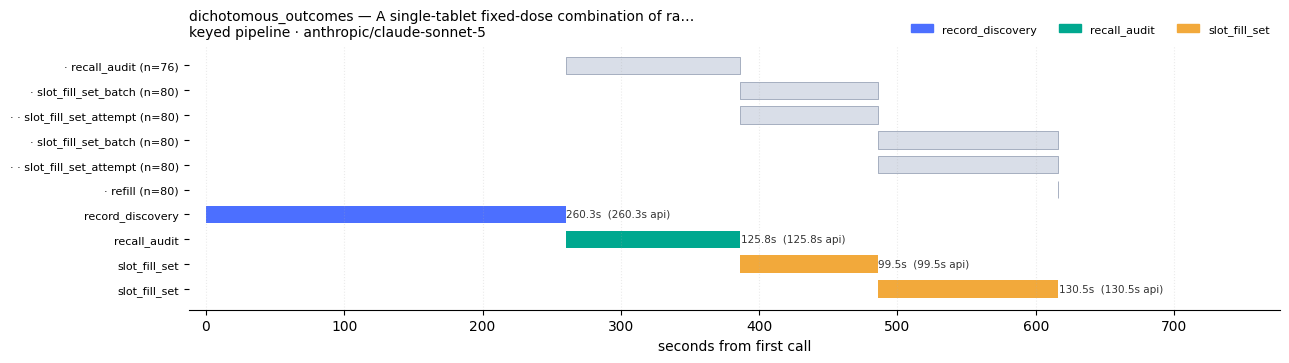

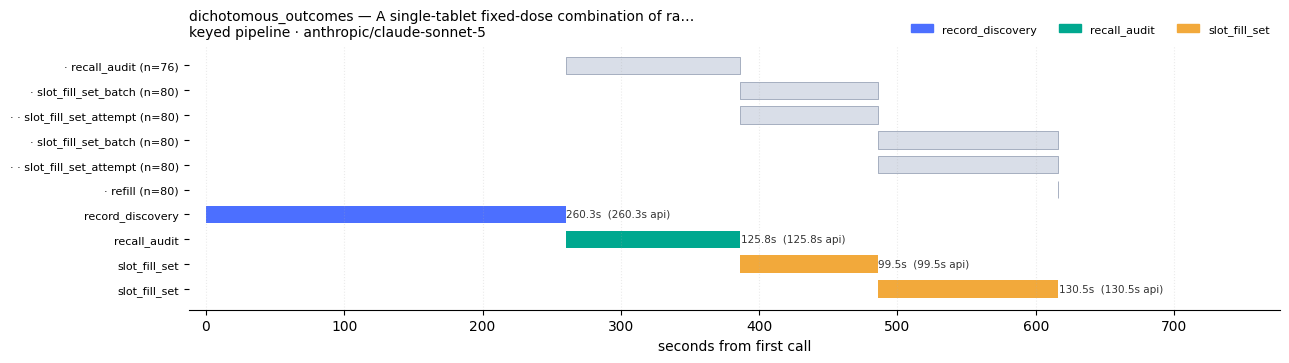

In [13]:
for p in sorted({c.paper for c in run.profiler.calls}):
    display(tt.waterfall(run, paper=p))

In [14]:
if SAVE:
    out_dir = tt.save_outputs(run, tag=f"{FIELD}")
    print("saved →", out_dir)

saved → /home/ubuntu/evistream/backend/eval/profiling/outputs/20260817_145048_outcomes


## 5 · What production actually took (free — no LLM calls)

The live run above is one paper under ideal conditions. These two tables are the real thing:
recent jobs with their **queue wait**, and per-step latency across every call in the window.

`queue_s` is `started_at − created_at` — the Celery wait. It is invisible to an in-process
profiler and is often the larger half of "why did this job take so long".

In [14]:
jobs = tt.prod_jobs(project_id=sel.project_id, limit=25)
jobs

,job_id,status,created_at,queue_s,run_s,n_docs,form_id,error
0,cae03b3c-8270-46ef-ba6c-68cebd2fdc8d,completed,2026-08-18T13:40:31.883067+00:00,0.0,850.1,1,d9f6e1d9-449e-4aaa-a438-67923f77a448,
1,f1b1d67c-468c-4a49-b43d-65de49ca0c0a,completed,2026-08-14T15:37:58.011281+00:00,0.0,38.3,3,eb128c95-1913-483d-8e62-b19c5eb10247,
2,36126e52-0b1d-437e-9eae-fa08bc731ac8,completed,2026-08-13T19:09:52.339199+00:00,0.0,58.9,12,ea16c6cc-e881-442f-9402-586af1bd930c,
3,c4a426b6-8ab7-4b3a-9f03-72aa3eea7c75,completed,2026-08-13T18:46:26.646982+00:00,3.1,951.5,1,d9f6e1d9-449e-4aaa-a438-67923f77a448,
4,bf5cc90f-a0cc-4797-a51b-a2c1c9a556d9,completed,2026-08-13T17:47:08.23879+00:00,0.1,57.4,6,7e7fc5dc-6244-4926-94c4-4a3c29973f4d,
5,7d22eb00-e8b0-44cf-9435-c42cc17786ae,completed,2026-08-13T12:31:41.512487+00:00,0.3,740.9,6,ded9d6ab-e9e6-4ce2-b409-3ec740c3f6c0,
6,3ba0c293-da39-4f78-b0de-11d68c5dbd70,completed,2026-08-13T00:22:24.043163+00:00,2.7,1157.0,1,d9f6e1d9-449e-4aaa-a438-67923f77a448,
7,675b0cc7-7ee8-4411-914e-aafe356bd08c,completed,2026-08-12T19:36:18.351135+00:00,2.9,1247.6,2,d9f6e1d9-449e-4aaa-a438-67923f77a448,
8,04f71a01-0e07-4f6c-aa81-c3fcde21d0bd,completed,2026-08-11T17:31:57.654823+00:00,0.0,169.1,6,d9f6e1d9-449e-4aaa-a438-67923f77a448,
9,720945d7-21dd-443c-b58b-3fa3577e275c,completed,2026-08-06T17:09:13.663937+00:00,0.0,50.5,4,ea16c6cc-e881-442f-9402-586af1bd930c,


In [15]:
prod = tt.prod_step_summary(
    schema_name=sel.schema_name,
    job_id=PROD_JOB_ID,
    days=PROD_LOOKBACK_DAYS,
)
print(f"schema {sel.schema_name} · last {PROD_LOOKBACK_DAYS} days")
prod

schema dynamic_d9f6e1d9_AcuteDentalPainDichotomousOutcomes · last 30 days


,step,calls,with_timing,median_s,p95_s,max_s,sum_s,retries,cache_read,cache_write,cost_usd
0,slot_fill,11.0,11.0,206.96,345.30,382.24,2270.0,0.0,317362.0,32458.0,3.475
1,record_discovery,5.0,5.0,351.09,433.13,453.37,1783.8,0.0,155072.0,0.0,2.753
2,recall_audit,5.0,5.0,142.32,187.17,197.89,732.9,0.0,25240.0,129832.0,1.390
3,extract,21.0,5.0,5.49,6.00,6.06,26.4,0.0,126736.0,238700.0,1.816
4,slot_fill_row,164.0,0.0,NaN,NaN,NaN,NaN,0.0,3362505.0,149975.0,2.588


`with_timing` < `calls` means some rows predate the Aug 2026 per-call labels: their step is
recovered by re-classifying the stored prompt, but they carry no duration, so they count toward
volume and cost, not latency. If it is 0, widen the window or pick a schema that has run since.

Two step names to read carefully here:

* `extract` rows are the form's **scalar** signatures, not table work — the schema runs those in
  the same job. Only `record_discovery` / `recall_audit` / `slot_fill` / `slot_fill_row` /
  `refill` belong to the table field.
* production stores `slot_fill` where this profiler says `slot_fill_set`; the comparison below
  renames via `tt.PROD_STEP_NAME` so the two line up.

The `cache_write` row is the one paying the 1.25× write rate — normally record discovery, since
it is the first call to touch the paper.

In [ ]:
# Live run vs production, per step.
if len(prod) and len(steps):
    live = steps.assign(step=steps.step.map(lambda s: tt.PROD_STEP_NAME.get(s, s)))
    cmp = (live.groupby("step", as_index=False)
               .agg(calls_live=("calls", "sum"), api_s_median_live=("api_s_median", "median"))
               .merge(prod[["step", "calls", "median_s", "p95_s"]].rename(
                   columns={"calls": "calls_prod", "median_s": "median_s_prod",
                            "p95_s": "p95_s_prod"}),
                   on="step", how="outer"))
    display(cmp)
else:
    print("nothing to compare — no prod rows in the window, or the live run made no calls")

## Notes — what changes these numbers

* **`EXTRACTION_BATCH_VALUES`** — unset defaults to `1`: set-at-a-time, up to ~40 records per
  call, so a 9-row table costs 3 calls total. Set it to `0` before starting the kernel for the
  row-at-a-time path (2 + one call per record), which is also the automatic fallback when a set
  call fails twice. Set-at-a-time was once disabled after a cost regression; the env default has
  since flipped back, so always read `slot_filling` in the runtime table rather than assuming.
* **`EXTRACTION_PROMPT_CACHE`** — with it off, every call re-sends the whole paper: latency and
  cost both climb, visible as `cache_read == 0` on every row.
* **DSPy's response cache** — `bootstrap()` disables it. Re-enable only if you *want* to measure
  cache hits (`bootstrap(disable_dspy_cache=False)`).
* **`MODEL_OVERRIDE`** — separates model latency from pipeline structure. The step *counts* stay
  the same; only `api_s` moves.
* **`USE_MODEL_ROUTER=False`** — skips the circuit breaker and `dspy.context`. Slightly faster,
  no longer production-shaped.
* **Agentic fields** — a field whose strategy resolves to `agentic` runs the Claude Agent SDK
  extractor, whose internal turns are not DSPy forwards, so only the outer span is timed.
* **Retries above the extractor** — `StagedPipeline` re-runs a whole extractor when every field
  comes back empty. This notebook profiles one extractor call, so that outer retry shows up in
  production numbers (section 5) but not here.
* **The `topics` kernel** matters: in `base`, `import dspy` fails or resolves to a different
  version than production runs.